In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/raw/Telco_churn.csv")

In [3]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
pd.set_option("display.max_columns", None)

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.describe(include = "all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


# Binary Encoding

In [7]:
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]

df[binary_cols] = df[binary_cols].replace({
    'Yes' : 1, 'No' : 0,
    'Male' : 1, 'Female' : 0
}).astype(int)

C:\Users\Victus\AppData\Local\Temp\ipykernel_16604\1801615110.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({


In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.5,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


# One-Hot Encoding

In [9]:
multi_cat_col = [
    'MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
    'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
    'Contract','PaymentMethod'
]

df = pd.get_dummies(df, columns = multi_cat_col, drop_first = True)

In [10]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


## Cleaning

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [12]:
df = df.drop("customerID", axis = 1)

In [13]:
bool_cols = df.select_dtypes(include = "bool").columns
df[bool_cols]  = df[bool_cols].astype(int)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

In [15]:
corr_matrix = df.corr(numeric_only = True)
churn_corr = corr_matrix[['Churn']].sort_values(by ='Churn', ascending = False)
print(churn_corr)

                                          Churn
Churn                                  1.000000
InternetService_Fiber optic            0.308020
PaymentMethod_Electronic check         0.301919
MonthlyCharges                         0.193356
PaperlessBilling                       0.191825
SeniorCitizen                          0.150889
StreamingTV_Yes                        0.063228
StreamingMovies_Yes                    0.061382
MultipleLines_Yes                      0.040102
PhoneService                           0.011942
gender                                -0.008612
MultipleLines_No phone service        -0.011942
DeviceProtection_Yes                  -0.066160
OnlineBackup_Yes                      -0.082255
PaymentMethod_Mailed check            -0.091683
PaymentMethod_Credit card (automatic) -0.134302
Partner                               -0.150448
Dependents                            -0.164221
TechSupport_Yes                       -0.164674
OnlineSecurity_Yes                    -0

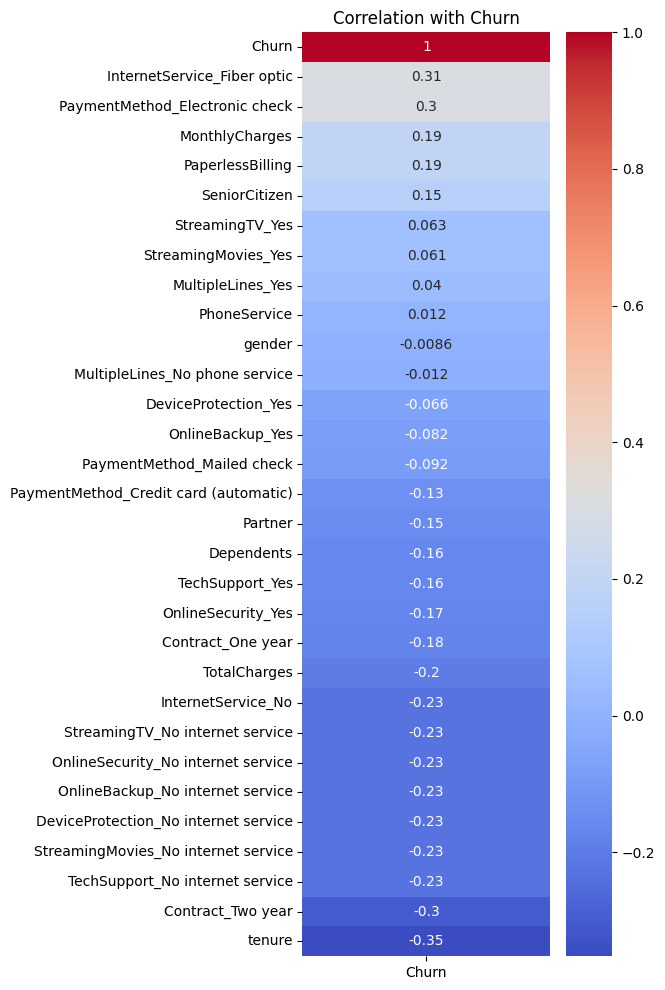

In [16]:
plt.figure(figsize = (4, 12))
sns.heatmap(churn_corr, annot = True, cmap = 'coolwarm')
plt.title("Correlation with Churn")
plt.show()

## Look for multicolinearity (VIF)

In [17]:
df["No_internet_service"] = (
    df['StreamingTV_No internet service']|
    df['OnlineSecurity_No internet service'] |
    df['OnlineBackup_No internet service']  |
    df['DeviceProtection_No internet service']|
    df['StreamingMovies_No internet service'] |  
    df['TechSupport_No internet service']  
).astype(int)

drop_cols = [col for col in df.columns if 'No internet service' in col]
df = df.drop(columns = drop_cols)

if 'MultipleLines_No phone service' in df.columns:
    df["No_phone_service"] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns = ['MultipleLines_No phone service'])

In [29]:
df.to_csv("../data/processed/processed_data.csv", index=False)

In [18]:
X = df.drop(columns=["Churn"])
bool_cols = X.select_dtypes(include = 'bool').columns
X[bool_cols] = X[bool_cols].astype(int)

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = X.replace([np.inf, -np.inf], np.nan).dropna()

vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by = "VIF", ascending = False)
print(vif_data)

d:\Projects\Telco_Customer_Churn_Predictor_With_MLFlow\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                  feature          VIF
11                     InternetService_No          inf
23                    No_internet_service          inf
5                            PhoneService  1773.528816
7                          MonthlyCharges   866.089640
10            InternetService_Fiber optic   148.500814
24                       No_phone_service    60.842267
17                    StreamingMovies_Yes    24.156394
16                        StreamingTV_Yes    24.080019
8                            TotalCharges    10.811490
4                                  tenure     7.584453
9                       MultipleLines_Yes     7.289761
14                   DeviceProtection_Yes     6.924754
13                       OnlineBackup_Yes     6.796678
15                        TechSupport_Yes     6.476508
12                     OnlineSecurity_Yes     6.338349
19                      Contract_Two year     2.652328
21         PaymentMethod_Electronic check     1.976032
22        

## Machine Learning

In [23]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.metrics import classification_report

import time

X = df.drop(columns = ['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)
Threshold = 0.3

In [46]:
rf = RandomForestClassifier(
    n_estimators = 500,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs = -1
)
rf.fit(X_train, y_train)
proba = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= Threshold).astype(int)

print(classification_report(y_test, y_pred, digits = 3))



              precision    recall  f1-score   support

           0      0.882     0.765     0.819      1035
           1      0.524     0.717     0.606       374

    accuracy                          0.752      1409
   macro avg      0.703     0.741     0.713      1409
weighted avg      0.787     0.752     0.763      1409



In [49]:
from sklearn.metrics import precision_score, recall_score, f1_score
proba = rf.predict_proba(X_test)[:, 1]

print("Threshold Tuning for Random Forest")
print(f"{'thresh' : <8}{'Prec_1': <8}{'Rec_1': <8}{'F1_1': <8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label = 1)
    rec = recall_score(y_test, preds, pos_label = 1)
    f1 = f1_score(y_test, preds, pos_label = 1)
    print(f"{thresh : <8}{prec: <8.3f}{rec: <8.3f}{f1: <8.3f}")

Threshold Tuning for Random Forest
thresh  Prec_1  Rec_1   F1_1    
0.25    0.498   0.786   0.610   
0.3     0.524   0.717   0.606   
0.35    0.546   0.671   0.602   
0.4     0.580   0.623   0.601   
0.45    0.602   0.551   0.575   
0.5     0.631   0.489   0.551   


In [52]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report
import time

lgbm = LGBMClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    class_weight = 'balanced', 
    random_state = 42,
    n_jobs = -1
)

start_train = time.time()
lgbm.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"⏱ Training time: {train_time:.2f} seconds")

start_pred = time.time()
proba = lgbm.predict_proba(X_test)[:, 1]
y_pred = (proba >= Threshold).astype(int)
pred_time = time.time() - start_pred
print(f"⏱ Prediction time: {pred_time:.2f} seconds")

print(classification_report(y_test, y_pred, digits = 3))




[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 627
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
⏱ Training time: 2.49 seconds
⏱ Prediction time: 0.02 seconds
              precision    recall  f1-score   support

           0      0.914     0.702     0.795      1035
           1      0.498     0.818     0.619       374

    accuracy                          0.733      1409
   macro avg      0.706     0.760     0.707      1409
weighted avg      0.804     0.733 

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score
proba = lgbm.predict_proba(X_test)[:, 1]

print("Threshold Tuning for LightGBM")
print(f"{'thresh' : <8}{'Prec_1': <8}{'Rec_1': <8}{'F1_1': <8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    prec = precision_score(y_test, preds, pos_label = 1)
    rec = recall_score(y_test, preds, pos_label = 1)
    f1 = f1_score(y_test, preds, pos_label = 1)
    print(f"{thresh : <8}{prec: <8.3f}{rec: <8.3f}{f1: <8.3f}")

Threshold Tuning for LightGBM
thresh  Prec_1  Rec_1   F1_1    
0.25    0.479   0.842   0.610   
0.3     0.498   0.818   0.619   
0.35    0.507   0.786   0.616   
0.4     0.524   0.757   0.619   
0.45    0.537   0.741   0.622   
0.5     0.552   0.701   0.617   
